# Austin Ionosonde Data Validation

This notebook loads and validates the Austin, TX (AU930) ionosonde data,
and creates visualization plots for data validation.

This is a supporting notebook for data validation - not a figure in the paper.

**Data Source:** 2024-04-08 manually-scaled ionosonde measurements by David Themens

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load Austin Ionosonde Data

The CSV file contains manually-scaled GIRO DIDBase ionosonde measurements:
- **Critical Frequencies** (MHz): foF2, foF1, foE
- **Virtual Heights** (km): hmF2, hmF1, hmE

Header information is preserved as comments (lines starting with #) at the top of the CSV file.

In [2]:
# Load the ionosonde data using the hf_tdoa library
# This uses the default Austin TX ionosonde data file
ionosonde_df = tdoa.load_ionosonde_data()

print(f"DataFrame shape: {ionosonde_df.shape}")
print(f"Columns: {ionosonde_df.columns.tolist()}")
print(f"Index: {ionosonde_df.index.name}")
print(f"\nDate range: {ionosonde_df.index.min()} to {ionosonde_df.index.max()}")
print(f"\nFirst few rows:")
display(ionosonde_df.head(10))
print(f"\nLast few rows:")
display(ionosonde_df.tail(10))
print(f"\nData summary:")
display(ionosonde_df.describe())

DataFrame shape: (288, 6)
Columns: ['foF2', 'foF1', 'foE', 'hmF2', 'hmF1', 'hmE']
Index: UTC

Date range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few rows:


,foF2,foF1,foE,hmF2,hmF1,hmE
UTC,,,,,,
2024-04-08 00:00:05,11.15,3.65,2.12,286.5,180.3,102.9
2024-04-08 00:05:05,11.35,3.35,NaN,296.1,171.9,NaN
2024-04-08 00:10:05,11.25,2.80,NaN,282.9,161.5,NaN
2024-04-08 00:15:05,11.35,2.92,NaN,286.6,169.5,NaN
2024-04-08 00:20:05,11.30,NaN,NaN,286.7,NaN,NaN
2024-04-08 00:25:05,11.35,NaN,NaN,281.9,NaN,NaN
2024-04-08 00:30:05,11.25,NaN,NaN,281.3,NaN,NaN
2024-04-08 00:35:05,11.15,NaN,NaN,276.8,NaN,NaN
2024-04-08 00:40:05,11.15,NaN,NaN,281.4,NaN,NaN



Last few rows:


,foF2,foF1,foE,hmF2,hmF1,hmE
UTC,,,,,,
2024-04-08 23:10:05,10.15,3.82,NaN,278.0,156.3,NaN
2024-04-08 23:15:05,10.20,NaN,NaN,280.3,NaN,NaN
2024-04-08 23:20:05,10.25,NaN,NaN,282.9,NaN,NaN
2024-04-08 23:25:05,10.15,4.15,NaN,279.1,174.6,NaN
2024-04-08 23:30:05,10.15,3.95,NaN,289.3,171.0,NaN
2024-04-08 23:35:05,10.25,3.75,NaN,284.4,166.5,NaN
2024-04-08 23:40:05,10.25,NaN,NaN,284.2,NaN,NaN
2024-04-08 23:45:05,10.35,3.40,NaN,281.4,161.7,NaN
2024-04-08 23:50:05,10.35,NaN,2.52,273.4,NaN,100.5



Data summary:


,foF2,foF1,foE,hmF2,hmF1,hmE
count,288.000000,125.000000,60.000000,288.000000,125.000000,60.000000
mean,8.257639,4.700560,3.043333,306.656944,171.058400,103.113333
std,2.260656,0.759891,0.385925,35.773900,8.245929,9.046593
min,5.300000,2.620000,1.820000,243.600000,150.900000,97.400000
25%,5.700000,4.150000,2.795000,279.200000,165.200000,100.500000
50%,8.850000,4.820000,3.120000,292.600000,172.000000,101.650000
75%,10.450000,5.350000,3.320000,343.775000,177.800000,103.250000
max,11.350000,5.850000,3.620000,383.700000,189.000000,169.800000


## Data Quality Check

Check for missing values and data coverage.

In [3]:
# Count missing values
print("Missing values per column:")
print(ionosonde_df.isnull().sum())
print(f"\nData coverage (% non-null):")
print((ionosonde_df.count() / len(ionosonde_df) * 100).round(1))

# Check time intervals
time_diffs = ionosonde_df.index.to_series().diff()
print(f"\nTime interval statistics:")
print(f"  Most common interval: {time_diffs.mode()[0]}")
print(f"  Min interval: {time_diffs.min()}")
print(f"  Max interval: {time_diffs.max()}")

Missing values per column:
foF2      0
foF1    163
foE     228
hmF2      0
hmF1    163
hmE     228
dtype: int64

Data coverage (% non-null):
foF2    100.0
foF1     43.4
foE      20.8
hmF2    100.0
hmF1     43.4
hmE      20.8
dtype: float64

Time interval statistics:
  Most common interval: 0 days 00:05:00
  Min interval: 0 days 00:05:00
  Max interval: 0 days 00:05:00


## Plot Virtual Heights

Plot hmF2, hmF1, and hmE (virtual heights of ionospheric layers).

Saved: validation_virtual_heights.jpg


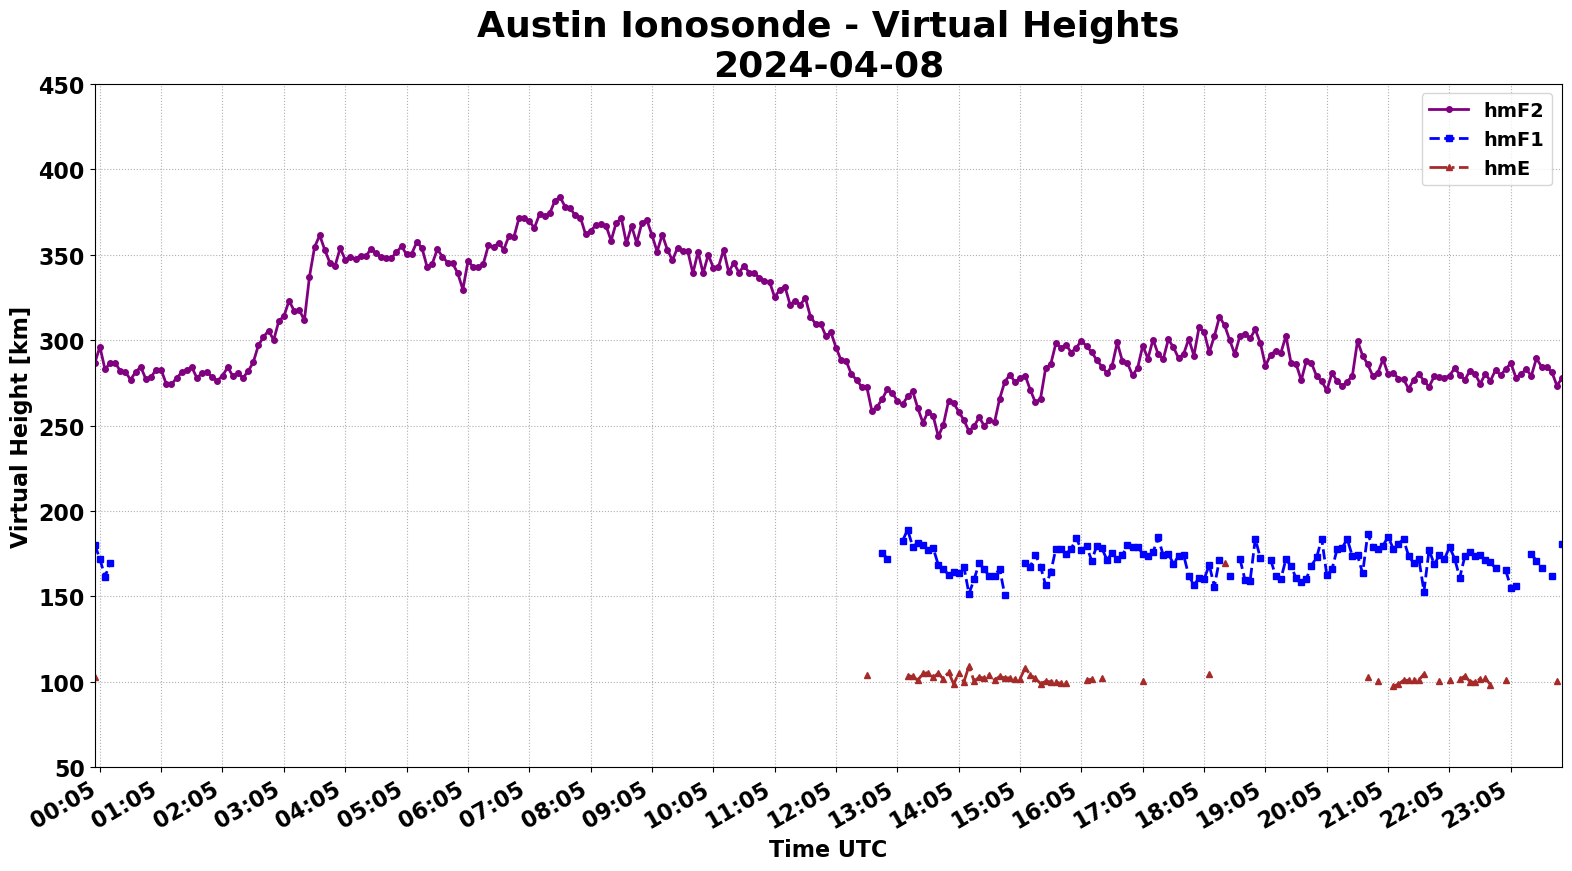

In [4]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot virtual heights
ax.plot(ionosonde_df.index, ionosonde_df['hmF2'], 
        label='hmF2', marker='o', linestyle='-', linewidth=2, markersize=4, color='purple')
ax.plot(ionosonde_df.index, ionosonde_df['hmF1'], 
        label='hmF1', marker='s', linestyle='--', linewidth=2, markersize=4, color='blue')
ax.plot(ionosonde_df.index, ionosonde_df['hmE'], 
        label='hmE', marker='^', linestyle='-.', linewidth=2, markersize=4, color='brown')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Virtual Height [km]')
ax.set_title('Austin Ionosonde - Virtual Heights\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(50, 450)

# Format datetime axis
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('validation_virtual_heights.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Saved: validation_virtual_heights.jpg")
plt.show()

## Plot Critical Frequencies

Plot foF2, foF1, and foE (critical frequencies of ionospheric layers).

Saved: validation_critical_frequencies.jpg


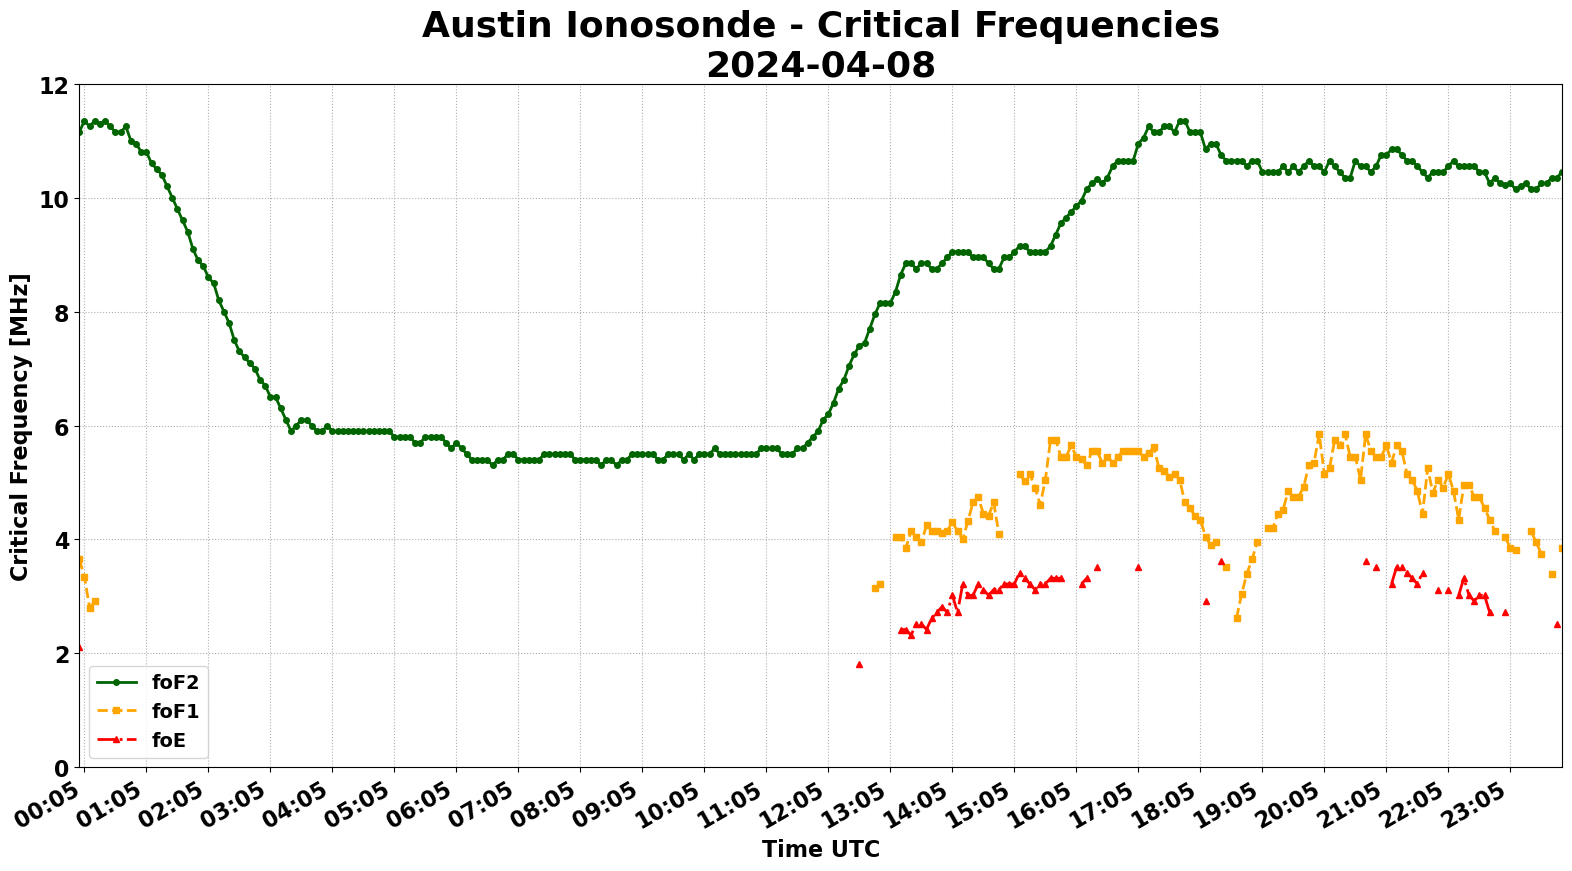

In [5]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot critical frequencies
ax.plot(ionosonde_df.index, ionosonde_df['foF2'], 
        label='foF2', marker='o', linestyle='-', linewidth=2, markersize=4, color='darkgreen')
ax.plot(ionosonde_df.index, ionosonde_df['foF1'], 
        label='foF1', marker='s', linestyle='--', linewidth=2, markersize=4, color='orange')
ax.plot(ionosonde_df.index, ionosonde_df['foE'], 
        label='foE', marker='^', linestyle='-.', linewidth=2, markersize=4, color='red')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Critical Frequency [MHz]')
ax.set_title('Austin Ionosonde - Critical Frequencies\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(0, 12)

# Format datetime axis
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('validation_critical_frequencies.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Saved: validation_critical_frequencies.jpg")
plt.show()

## Data Available for Further Analysis

The `ionosonde_df` DataFrame is now loaded and ready for use.

You can access the data in subsequent cells for custom analysis or plotting.

In [6]:
# Example: Access specific columns or time ranges
print("Example data access:")
print(f"\nhmF2 statistics:")
print(f"  Mean: {ionosonde_df['hmF2'].mean():.1f} km")
print(f"  Std:  {ionosonde_df['hmF2'].std():.1f} km")
print(f"  Min:  {ionosonde_df['hmF2'].min():.1f} km")
print(f"  Max:  {ionosonde_df['hmF2'].max():.1f} km")

print(f"\nfoF2 statistics:")
print(f"  Mean: {ionosonde_df['foF2'].mean():.2f} MHz")
print(f"  Std:  {ionosonde_df['foF2'].std():.2f} MHz")
print(f"  Min:  {ionosonde_df['foF2'].min():.2f} MHz")
print(f"  Max:  {ionosonde_df['foF2'].max():.2f} MHz")

print("\n✓ ionosonde_df is ready for further analysis!")

Example data access:

hmF2 statistics:
  Mean: 306.7 km
  Std:  35.8 km
  Min:  243.6 km
  Max:  383.7 km

foF2 statistics:
  Mean: 8.26 MHz
  Std:  2.26 MHz
  Min:  5.30 MHz
  Max:  11.35 MHz

✓ ionosonde_df is ready for further analysis!
